<a href="https://colab.research.google.com/github/tsuka22120/4IE2/blob/main/ED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ■■■ 1. ライブラリのインストール ■■■
!pip install geemap geopandas osmnx contextily tqdm shapely

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.5/101.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.4 MB/s eta 0:00:00



✅ GEEの認証と初期化が完了しました。

--- 水力発電ポテンシャル分析を開始します ---
➡️  ステップ 1/8: 基本設定を読み込んでいます...
   - "['長野市, 長野県', '白馬村,長野県']" の境界情報を取得中...
   - 範囲を特定しました: [np.float64(137.750019), np.float64(36.460702), np.float64(138.318899), np.float64(36.8357344)]
➡️  ステップ 2/8: Google Earth Engineから地形・河川データを取得します...
   - GEEからColab環境へデータを転送中...
   - 354本の河川セグメントを取得しました。
➡️  ステップ 3/8: OpenStreetMapからインフラ・環境データを取得します...
   - 道路網を取得中...
   - 送電網を取得中...
   - 保護地域を取得中...
➡️  ステップ 4/8: 各河川の発電ポテンシャルを評価し、候補地点を定義します...


[評価中] 河川セグメント:   0%|          | 0/354 [00:00<?, ?it/s]

   - 271箇所のポテンシャル評価が完了しました。
➡️  ステップ 5/8: インフラへのアクセスと環境制約を評価します...


[評価中] 道路への距離:   0%|          | 0/271 [00:00<?, ?it/s]

[評価中] 送電網への距離:   0%|          | 0/271 [00:00<?, ?it/s]

➡️  ステップ 6/8: 最終候補地を選定する前に、診断情報を表示します...

--- 診断レポート ---
評価対象の全ポテンシャルサイト数: 271件

各フィルタリング条件を満たさなかったサイト数:
  - 推定発電量が不足: 7件
  - 道路から遠すぎる: 0件
  - 送電網から遠すぎる: 0件
  - 保護地域内にある: 1件
---------------------

参考: ポテンシャル上位10件のフィルタリング状況（True=条件クリア）
     estimated_power_kw  dist_to_road_m  dist_to_power_m  in_park
238             57380.0       4042716.1        4009728.2    False
235             36237.8       4042716.1        4009728.2    False
228             35031.8       4042716.0        4009728.1     True
229             33758.5       4042716.0        4009728.1    False
233             26127.5       4042716.0        4009728.1    False
239             23148.6       4042715.9        4009728.0    False
230             18014.5       4042716.0        4009728.1    False
258             16632.2       4042715.9        4009728.0    False
9               14619.5       4042715.9        4009728.0    False
232             14433.9       4042716.0        4009728.1    False

診断完了。次に最終的なフィルタリングを行います。
➡️  ステップ 7/8:

/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/tmp/ipython-input-1661520867.py:210: UserWarning: Glyph 25512 (\N{CJK UNIFIED IDEOGRAPH-63A8}) missing from font(s) Liberation Sans.
  plt.tight_layout(); plt.show()
/tmp/ipython-input-1661520867.py:210: UserWarning: Glyph 23450 (\N{CJK UNIFIED IDEOGRAPH-5B9A}) missing from font(s) Liberation Sans.
  plt.tight_layout(); plt.show()
/tmp/ipython-input-1661520867.py:210: UserWarning: Glyph 30330 (\N{CJK UNIFIED IDEOGRAPH-767A}) missing from font(s) Liberation Sans.
  plt.tight_layout(); plt.show()
/tmp/ipython-input-1661520867.py:210: UserWarning: Glyph 38651 (\N{CJK UNIFIED IDEOGRAPH-96FB}) missing f

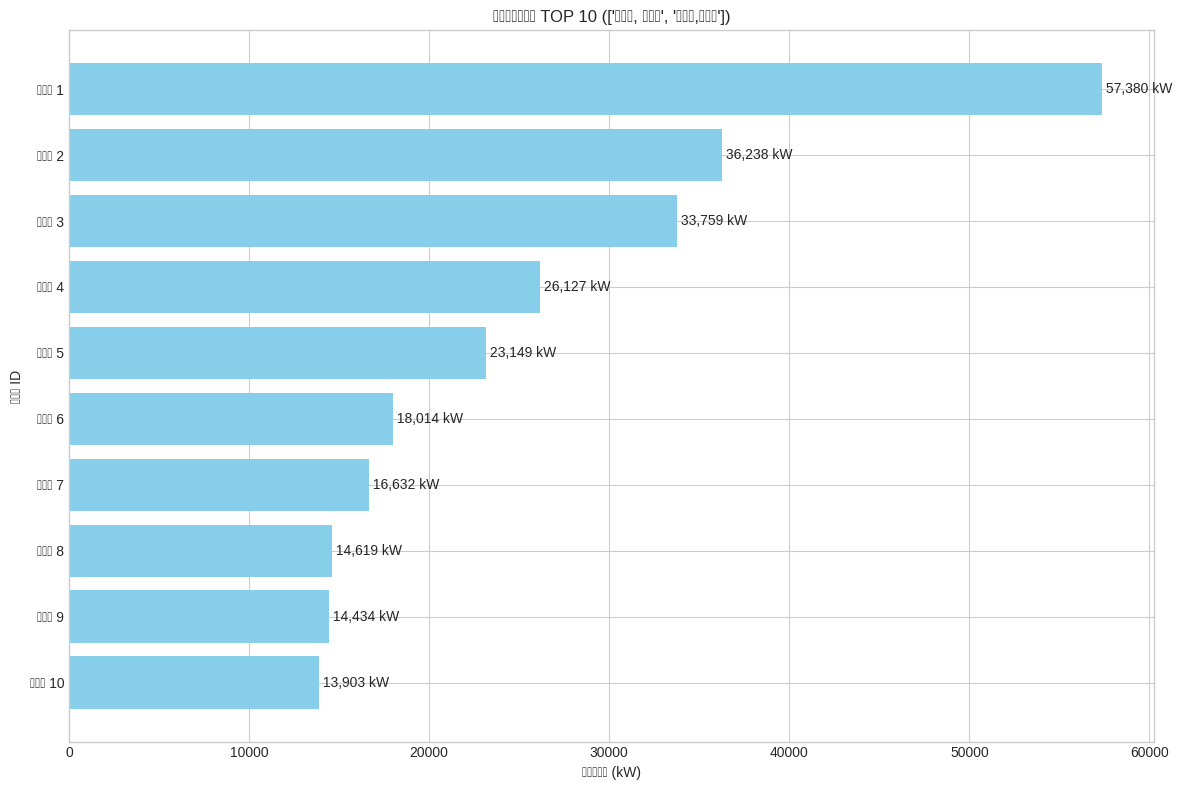

AttributeError: 'Series' object has no attribute 'to_crs'

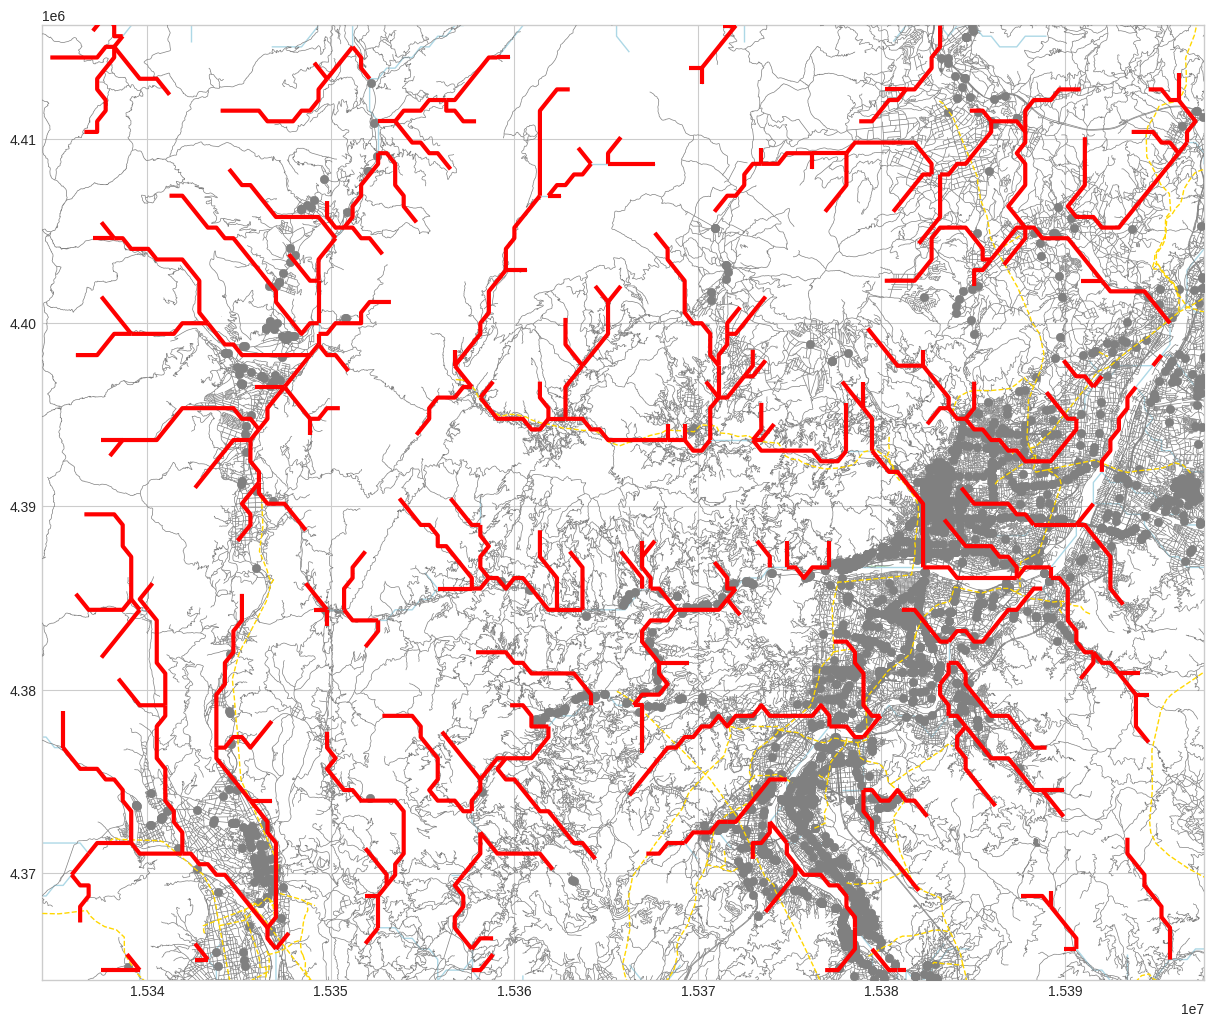

In [ ]:
# ■■■ 1. ライブラリのインストール ■■■
!pip install geemap geopandas osmnx contextily tqdm shapely --quiet

# ■■■ 2. ライブラリのインポートと認証 ■■■
import ee
import geemap
import os
import pandas as pd
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import contextily as cx
from tqdm.auto import tqdm
from shapely.geometry import box, Point, LineString
import numpy as np

# --- Google Earth Engineの認証と初期化 ---
try:
    ee.Initialize(project='arched-curve-461805-s7')
except Exception as e:
    print("Google Earth Engineの認証を行います...")
    ee.Authenticate()
    ee.Initialize(project='arched-curve-461805-s7')

print("\n✅ GEEの認証と初期化が完了しました。")


# ■■■ 3. 分析の実行 ■■■

print("\n--- 水力発電ポテンシャル分析を開始します ---")

# --- ステップ 1/8: 基本設定 ---
print("➡️  ステップ 1/8: 基本設定を読み込んでいます...")

# ここに分析したい市町村名や地域名を入力してください。
place_name = ["長野市, 長野県","白馬村,長野県"]

# ▼▼▼【変更箇所】フィルタリング条件をここに集約 ▼▼▼
# 保護地域内の候補地を除外するかどうか (True: 除外する / False: 含める)
EXCLUDE_PROTECTED_AREAS = True

# その他のフィルタリング条件
MIN_POWER_KW = 10
MAX_DIST_ROAD_M = 5000000
MAX_DIST_POWER_M = 50000000
# ▲▲▲ 変更ここまで ▲▲▲

try:
    print(f'   - "{place_name}" の境界情報を取得中...')
    area_gdf = ox.geocode_to_gdf(place_name)
    minx, miny, maxx, maxy = area_gdf.total_bounds
    bbox = [minx, miny, maxx, maxy]
    print(f'   - 範囲を特定しました: {bbox}')
except Exception as e:
    print(f"❌エラー: 地名 '{place_name}' が見つかりませんでした。別の名称でお試しください。")
    raise e

aoi = ee.Geometry.Rectangle(bbox)
candidates_path = '/content/hydropower_candidates.geojson'
CRS_WGS84 = "EPSG:4326"
CRS_UTM = "EPSG:32654"

# --- ステップ 2/8: GEEからのデータ取得 ---
print("➡️  ステップ 2/8: Google Earth Engineから地形・河川データを取得します...")
dem = ee.Image('USGS/SRTMGL1_003').clip(aoi)
rivers_ee = ee.FeatureCollection('WWF/HydroSHEDS/v1/FreeFlowingRivers').filterBounds(aoi)
print("   - GEEからColab環境へデータを転送中...")
rivers_gdf = geemap.ee_to_gdf(rivers_ee)
print(f"   - {len(rivers_gdf)}本の河川セグメントを取得しました。")

if rivers_gdf.empty:
    print(f"\n⚠️ 指定範囲 ({place_name}) に分析可能な河川が見つかりませんでした。処理を中断します。")
else:
    # --- ステップ 3/8: OSMからのインフラ・環境データ取得 ---
    print("➡️  ステップ 3/8: OpenStreetMapからインフラ・環境データを取得します...")
    tags_highway = {"highway": True}
    tags_power = {"power": ["line", "minor_line", "cable"]}
    tags_parks = {"boundary": "protected_area"}

    from osmnx._errors import InsufficientResponseError

    print("   - 道路網を取得中...")
    try:
        roads_gdf = ox.features.features_from_bbox(bbox, tags_highway)
    except InsufficientResponseError:
        print("     -> 道路データが見つかりませんでした。")
        roads_gdf = gpd.GeoDataFrame(columns=['geometry'], crs=CRS_WGS84)

    print("   - 送電網を取得中...")
    try:
        power_gdf = ox.features.features_from_bbox(bbox, tags_power)
    except InsufficientResponseError:
        print("     -> 送電網データが見つかりませんでした。")
        power_gdf = gpd.GeoDataFrame(columns=['geometry'], crs=CRS_WGS84)

    print("   - 保護地域を取得中...")
    try:
        parks_gdf = ox.features.features_from_bbox(bbox, tags_parks)
    except InsufficientResponseError:
        print("     -> 保護地域データが見つかりませんでした。")
        parks_gdf = gpd.GeoDataFrame(columns=['geometry'], crs=CRS_WGS84)

    # --- ステップ 4/8: ポテンシャル評価と地点定義 ---
    print("➡️  ステップ 4/8: 各河川の発電ポテンシャルを評価し、候補地点を定義します...")
    # (このステップは変更なし)
    results = []
    for index, row in tqdm(rivers_gdf.iterrows(), total=rivers_gdf.shape[0], desc="[評価中] 河川セグメント"):
        coords = list(row.geometry.coords)
        if len(coords) < 2: continue
        intake_point, power_plant_point = Point(coords[0]), Point(coords[-1])
        intake_ee, plant_ee = ee.Geometry.Point(coords[0]), ee.Geometry.Point(coords[-1])
        intake_elev = dem.reduceRegion(ee.Reducer.first(), intake_ee, 30).get('elevation').getInfo()
        plant_elev = dem.reduceRegion(ee.Reducer.first(), plant_ee, 30).get('elevation').getInfo()
        if intake_elev is None or plant_elev is None: continue
        head = intake_elev - plant_elev
        if head <= 0: continue
        flow = row['DIS_AV_CMS']
        if flow is None or flow <= 0: flow = 0
        POWER_EFFICIENCY = 0.85
        estimated_power_kw = head * flow * 9.8 * POWER_EFFICIENCY
        results.append({
            'geometry': row.geometry, 'intake_geom': intake_point, 'plant_geom': power_plant_point,
            'head_m': head, 'flow_m3_s': flow, 'estimated_power_kw': estimated_power_kw,
            'intake_elev_m': intake_elev, 'plant_elev_m': plant_elev
        })
    potential_gdf = gpd.GeoDataFrame(results, crs=CRS_WGS84)
    print(f"   - {len(potential_gdf)}箇所のポテンシャル評価が完了しました。")

    # --- ステップ 5/8: 周辺環境の評価 ---
    print("➡️  ステップ 5/8: インフラへのアクセスと環境制約を評価します...")
    potential_utm = potential_gdf.to_crs(CRS_UTM)
    roads_utm = roads_gdf.to_crs(CRS_UTM)
    power_utm = power_gdf.to_crs(CRS_UTM)
    parks_utm = parks_gdf.to_crs(CRS_UTM)

    tqdm.pandas(desc="[評価中] 道路への距離")
    potential_utm['dist_to_road_m'] = potential_utm['intake_geom'].progress_apply(lambda g: roads_utm.distance(g).min() if not roads_utm.empty else float('inf'))
    tqdm.pandas(desc="[評価中] 送電網への距離")
    potential_utm['dist_to_power_m'] = potential_utm['intake_geom'].progress_apply(lambda g: power_utm.distance(g).min() if not power_utm.empty else float('inf'))

    # ▼▼▼【変更箇所】DeprecationWarningを修正 ▼▼▼
    potential_utm['in_park'] = potential_utm.intersects(parks_utm.union_all()) if not parks_utm.empty else False
    # ▲▲▲ 変更ここまで ▲▲▲

    # --- ▼▼▼【新規追加】ステップ 6/8: フィルタリング前の診断分析 ▼▼▼ ---
    print("➡️  ステップ 6/8: 最終候補地を選定する前に、診断情報を表示します...")

    # 全てのポテンシャルサイトを評価
    diag_df = potential_utm.copy()
    diag_df['passes_power'] = diag_df['estimated_power_kw'] >= MIN_POWER_KW
    diag_df['passes_road'] = diag_df['dist_to_road_m'] <= MAX_DIST_ROAD_M
    diag_df['passes_power_line'] = diag_df['dist_to_power_m'] <= MAX_DIST_POWER_M
    diag_df['is_outside_park'] = ~diag_df['in_park']

    print("\n--- 診断レポート ---")
    print(f"評価対象の全ポテンシャルサイト数: {len(diag_df)}件")
    print("\n各フィルタリング条件を満たさなかったサイト数:")
    print(f"  - 推定発電量が不足: {len(diag_df[~diag_df['passes_power']])}件")
    print(f"  - 道路から遠すぎる: {len(diag_df[~diag_df['passes_road']])}件")
    print(f"  - 送電網から遠すぎる: {len(diag_df[~diag_df['passes_power_line']])}件")
    print(f"  - 保護地域内にある: {len(diag_df[~diag_df['is_outside_park']])}件")
    print("---------------------\n")

    print("参考: ポテンシャル上位10件のフィルタリング状況（True=条件クリア）")
    display_cols = ['estimated_power_kw', 'dist_to_road_m', 'dist_to_power_m', 'in_park']
    # データを丸めて見やすくする
    diag_display = diag_df.sort_values('estimated_power_kw', ascending=False).head(10)[display_cols].round(1)
    print(diag_display)
    print("\n診断完了。次に最終的なフィルタリングを行います。")
    # --- ▲▲▲ 新規追加ここまで ▲▲▲ ---


    # --- ステップ 7/8: 最終候補地の選定とランキング ---
    print("➡️  ステップ 7/8: 条件に基づき最終候補地をフィルタリングし、順位付けします...")

    # フィルタリングのベースを作成
    candidates_gdf = potential_utm[
        (potential_utm['estimated_power_kw'] >= MIN_POWER_KW) &
        (potential_utm['dist_to_road_m'] <= MAX_DIST_ROAD_M) &
        (potential_utm['dist_to_power_m'] <= MAX_DIST_POWER_M)
    ]

    # ▼▼▼【変更箇所】保護地域フィルターをON/OFFできるように変更 ▼▼▼
    if EXCLUDE_PROTECTED_AREAS:
        print("   - 保護地域内の候補地を除外します。")
        candidates_gdf = candidates_gdf[~candidates_gdf['in_park']]
    else:
        print("   - 注意: 保護地域内の候補地も結果に含めます。")
    # ▲▲▲ 変更ここまで ▲▲▲

    candidates_gdf = candidates_gdf.sort_values('estimated_power_kw', ascending=False).reset_index(drop=True)

    print(f"✅ 評価完了！ {len(candidates_gdf)}箇所の有望な候補地が見つかりました。")

    # --- ステップ 8/8: 結果の可視化と出力 ---
    print("➡️  ステップ 8/8: 結果をグラフと地図で可視化し、ファイルを出力します...")

    if not candidates_gdf.empty:
        # (グラフと地図の描画、ファイル出力は変更なし)
        plt.style.use('seaborn-v0_8-whitegrid')
        fig_bar, ax_bar = plt.subplots(figsize=(12, 8))
        top_n = min(len(candidates_gdf), 10)
        top_candidates = candidates_gdf.head(top_n)
        top_candidates['candidate_id'] = [f"候補地 {i+1}" for i in range(top_n)]
        ax_bar.barh(top_candidates['candidate_id'], top_candidates['estimated_power_kw'], color='skyblue')
        ax_bar.set_xlabel('推定発電量 (kW)'); ax_bar.set_ylabel('候補地 ID')
        ax_bar.set_title(f'水力発電候補地 TOP {top_n} ({place_name})'); ax_bar.invert_yaxis()
        for index, value in enumerate(top_candidates['estimated_power_kw']):
            ax_bar.text(value, index, f' {value:,.0f} kW', va='center')
        plt.tight_layout(); plt.show()

        fig_map, ax_map = plt.subplots(1, 1, figsize=(15, 15))
        area_mercator = area_gdf.to_crs(epsg=3857)
        ax_map.set_xlim(area_mercator.total_bounds[0], area_mercator.total_bounds[2])
        ax_map.set_ylim(area_mercator.total_bounds[1], area_mercator.total_bounds[3])
        rivers_gdf.to_crs(epsg=3857).plot(ax=ax_map, color='lightblue', linewidth=1, label='全ての河川', zorder=2)
        if not roads_gdf.empty: roads_gdf.to_crs(epsg=3857).plot(ax=ax_map, color='gray', linewidth=0.5, label='道路', zorder=3)
        if not power_gdf.empty: power_gdf.to_crs(epsg=3857).plot(ax=ax_map, color='gold', linewidth=1, linestyle='--', label='送電網', zorder=4)
        if not parks_gdf.empty: parks_gdf.to_crs(epsg=3857).plot(ax=ax_map, color='green', alpha=0.3, label='保護地域', zorder=1)

        candidates_gdf.to_crs(epsg=3857).plot(ax=ax_map, color='red', linewidth=3, label='候補の河川区間', zorder=5)
        candidates_gdf['intake_geom'].to_crs(epsg=3857).plot(ax=ax_map, marker='o', color='blue', markersize=50, label='取水口', zorder=6)
        candidates_gdf['plant_geom'].to_crs(epsg=3857).plot(ax=ax_map, marker='^', color='darkred', markersize=70, label='発電所', zorder=6)
        area_mercator.plot(ax=ax_map, facecolor='none', edgecolor='black', linestyle='-.', linewidth=2, label=f'{place_name} の境界', zorder=7)

        cx.add_basemap(ax_map, source=cx.providers.GSI.Pale)
        ax_map.set_title(f'水力発電 最終候補地マップ ({place_name})')
        ax_map.legend(loc='upper left')
        plt.axis('off'); plt.show()

        from google.colab import files
        candidates_gdf.to_crs(CRS_WGS84).to_file(candidates_path, driver='GeoJSON')
        print(f"\n結果ファイル '{os.path.basename(candidates_path)}' をダウンロードします...")
        files.download(candidates_path)

    else:
        print(f"\nℹ️ 設定された条件を満たす候補地は {place_name} には見つかりませんでした。")
        print("   - 診断レポートを確認し、それでも候補地が見つからない場合は、コード先頭のフィルタリング条件をさらに緩和するか、別の地域で再試行してみてください。")
        print("   - 特に、保護地域が原因で多くの候補が除外されている場合、`EXCLUDE_PROTECTED_AREAS = False` に設定して再度実行することをお勧めします。")

Google Earth Engineの認証を行います...

認証と初期化が完了しました。プロジェクト: arched-curve-461805-s7

1. 基本設定を開始します...
2. Google Earth EngineからHydroSHEDSデータセットを取得します...
   - 解析結果をColab環境に転送しています...
3. 事業性評価を開始します...
   - 落差と流量ポテンシャルを計算中...


河川セグメントを評価中:   0%|          | 0/1391 [00:00<?, ?it/s]

   - OSMから追加情報を取得・評価中...
     - 道路網を取得中...
     - 送電網を取得中...
     - 保護地域を取得中...
4. 最終候補地を選定しています...
評価が完了し、55箇所の候補地が見つかりました。
5. 最終候補地を地図上にプロットします...


/tmp/ipython-input-593862508.py:152: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='upper left'); plt.axis('off'); plt.show()


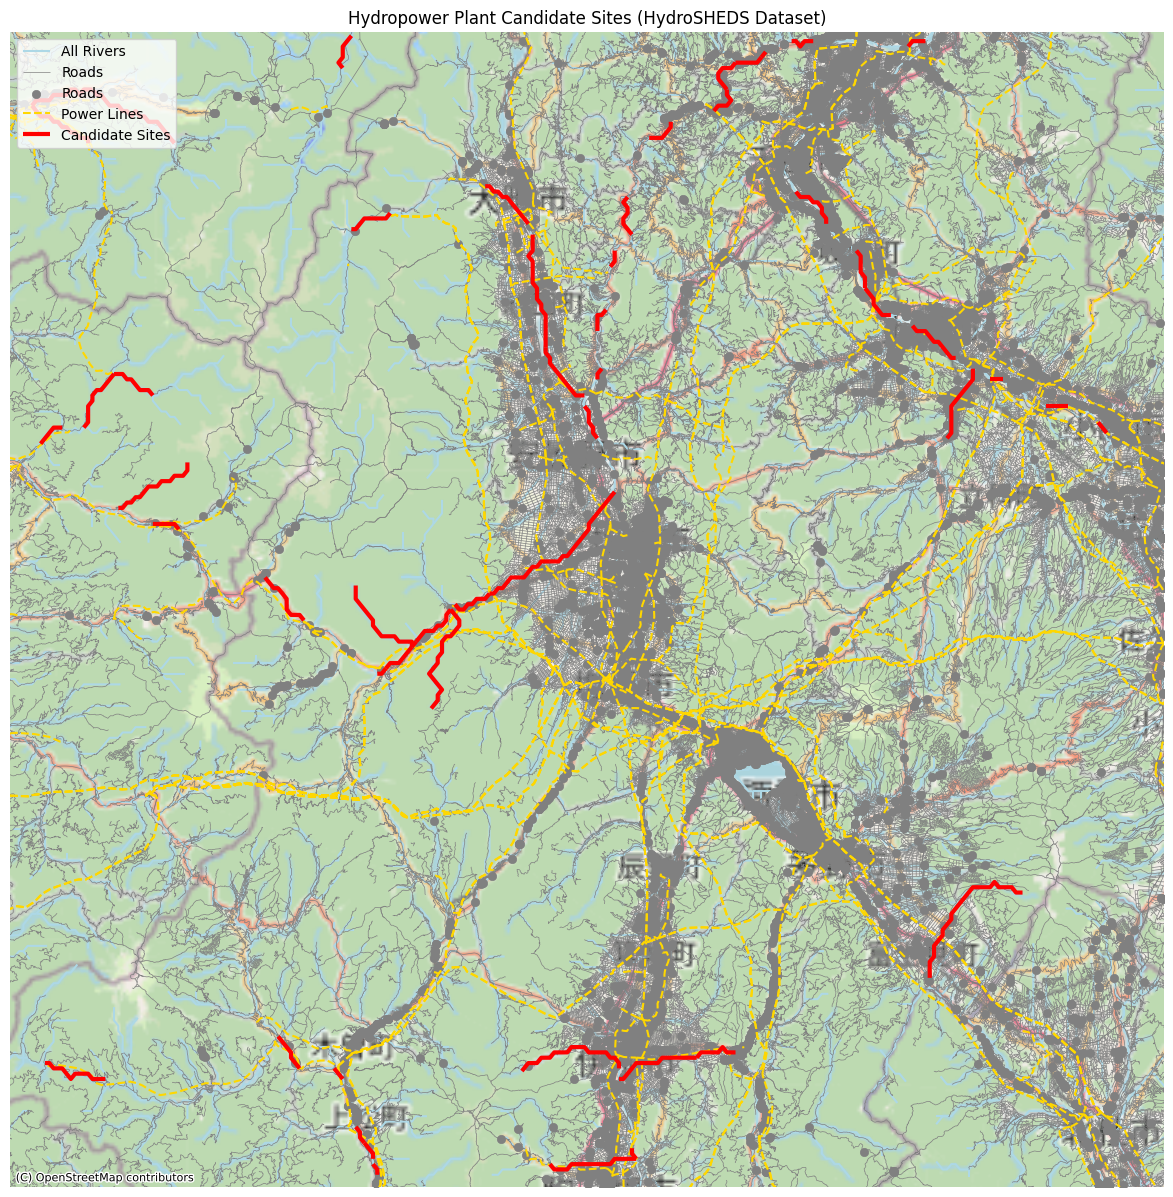


結果ファイル 'candidates_final.geojson' をダウンロードします...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ■■■ 3. 認証、インポート、分析、可視化、ダウンロード ■■■

# --- ライブラリのインポート ---
import ee
import geemap
import os
import pandas as pd
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import contextily as cx
from tqdm.auto import tqdm
# ▼▼▼【変更箇所】地図の範囲設定に必要なライブラリを追加 ▼▼▼
from shapely.geometry import box
# ▲▲▲ 変更ここまで ▲▲▲

# --- Google CloudプロジェクトIDの設定 ---
# あなたのIDを反映しました
cloud_project_id = 'arched-curve-461805-s7'

# --- Google Earth Engineの認証と初期化 ---
try:
    ee.Initialize(project=cloud_project_id)
except Exception as e:
    print("Google Earth Engineの認証を行います...")
    ee.Authenticate()
    ee.Initialize(project=cloud_project_id)
print(f"\n認証と初期化が完了しました。プロジェクト: {cloud_project_id}")

# --- 1. 基本設定 ---
print("\n1. 基本設定を開始します...")
candidates_path = '/content/candidates_final.geojson'
bbox = [137.360, 35.730, 138.474, 36.630] #アルフィン周辺
aoi = ee.Geometry.Rectangle(bbox)

# --- 2. GEEでの河川データ取得 ---
print("2. Google Earth EngineからHydroSHEDSデータセットを取得します...")
rivers_ee = ee.FeatureCollection('WWF/HydroSHEDS/v1/FreeFlowingRivers').filterBounds(aoi)
dem = ee.Image('USGS/SRTMGL1_003').clip(aoi)

print("   - 解析結果をColab環境に転送しています...")
rivers_gdf = geemap.ee_to_gdf(rivers_ee)

if rivers_gdf.empty:
    print("指定範囲に河川が見つかりませんでした。処理を中断します。")
else:
    # --- 3. 事業性評価 ---
    print("3. 事業性評価を開始します...")
    print("   - 落差と流量ポテンシャルを計算中...")
    potentials = []

    for index, row in tqdm(rivers_gdf.iterrows(), total=rivers_gdf.shape[0], desc="河川セグメントを評価中"):
        coords = list(row.geometry.coords)
        if not coords: continue
        start_point, end_point = ee.Geometry.Point(coords[0]), ee.Geometry.Point(coords[-1])
        start_elev = dem.reduceRegion(ee.Reducer.first(), start_point, 30).get('elevation').getInfo()
        end_elev = dem.reduceRegion(ee.Reducer.first(), end_point, 30).get('elevation').getInfo()
        if start_elev is None or end_elev is None: head = 0
        else: head = start_elev - end_elev
        if head < 0: head = 0
        flow_proxy = row['DIS_AV_CMS']
        if flow_proxy is None: flow_proxy = 0
        potentials.append(head * flow_proxy)

    rivers_gdf['potential'] = potentials

    print("   - OSMから追加情報を取得・評価中...")
    tags_highway = {"highway": True}
    tags_power = {"power": ["line", "minor_line", "cable"]}
    tags_parks = {"boundary": "protected_area"}

    print("     - 道路網を取得中...")
    try:
        roads_gdf = ox.features.features_from_bbox(bbox, tags_highway)
    except Exception as e:
        if "No matching features" in str(e):
            print("       -> 道路データが見つかりませんでした。")
            roads_gdf = gpd.GeoDataFrame(columns=['geometry'], geometry='geometry', crs="EPSG:4326")
        else: raise e

    print("     - 送電網を取得中...")
    try:
        power_gdf = ox.features.features_from_bbox(bbox, tags_power)
    except Exception as e:
        if "No matching features" in str(e):
            print("       -> 送電網データが見つかりませんでした。")
            power_gdf = gpd.GeoDataFrame(columns=['geometry'], geometry='geometry', crs="EPSG:4326")
        else: raise e

    print("     - 保護地域を取得中...")
    try:
        parks_gdf = ox.features.features_from_bbox(bbox, tags_parks)
    except Exception as e:
        if "No matching features" in str(e):
            print("       -> 保護地域データが見つかりませんでした。")
            parks_gdf = gpd.GeoDataFrame(columns=['geometry'], geometry='geometry', crs="EPSG:4326")
        else: raise e

    utm_crs = "EPSG:32654"
    rivers_utm = rivers_gdf.to_crs(utm_crs)
    if not roads_gdf.empty: rivers_utm['dist_to_road_m'] = rivers_utm.geometry.apply(lambda g: roads_gdf.to_crs(utm_crs).distance(g).min())
    else: rivers_utm['dist_to_road_m'] = 99999
    if not power_gdf.empty: rivers_utm['dist_to_power_m'] = rivers_utm.geometry.apply(lambda g: power_gdf.to_crs(utm_crs).distance(g).min())
    else: rivers_utm['dist_to_power_m'] = 99999

    if not parks_gdf.empty:
        rivers_utm['in_park'] = False
        intersecting_indices = gpd.sjoin(rivers_utm, parks_gdf.to_crs(utm_crs), how='inner', predicate='intersects').index
        if not intersecting_indices.empty:
            rivers_utm.loc[intersecting_indices, 'in_park'] = True
    else:
        rivers_utm['in_park'] = False

    # --- 4. 候補地の選定 ---
    print("4. 最終候補地を選定しています...")
    valid_potentials = rivers_utm[rivers_utm['potential'] > 0]['potential']
    if not valid_potentials.empty:
        potential_threshold = valid_potentials.quantile(0.95)
        max_dist_road, max_dist_power = 1000, 5000
        candidates_gdf = rivers_utm[
            (rivers_utm['potential'] >= potential_threshold) & (rivers_utm['dist_to_road_m'] <= max_dist_road) &
            (rivers_utm['dist_to_power_m'] <= max_dist_power) & (~rivers_utm['in_park'])
        ]
        if not candidates_gdf.empty:
            candidates_gdf.to_file(candidates_path, driver='GeoJSON')
    else:
        candidates_gdf = gpd.GeoDataFrame()
    print(f"評価が完了し、{len(candidates_gdf)}箇所の候補地が見つかりました。")

    # --- 5. 最終結果の可視化 ---
    print("5. 最終候補地を地図上にプロットします...")
    fig, ax = plt.subplots(1, 1, figsize=(15, 15))
    if not rivers_gdf.empty: rivers_gdf.to_crs(epsg=3857).plot(ax=ax, color='lightblue', linewidth=1.5, label='All Rivers', zorder=2)
    if not roads_gdf.empty: roads_gdf.to_crs(epsg=3857).plot(ax=ax, color='gray', linewidth=0.5, label='Roads', zorder=3)
    if not power_gdf.empty: power_gdf.to_crs(epsg=3857).plot(ax=ax, color='gold', linewidth=1.5, linestyle='--', label='Power Lines', zorder=4)
    if not parks_gdf.empty: parks_gdf.to_crs(epsg=3857).plot(ax=ax, color='green', alpha=0.3, label='Protected Areas', zorder=1)
    if 'candidates_gdf' in locals() and not candidates_gdf.empty:
        candidates_gdf.to_crs(epsg=3857).plot(ax=ax, color='red', linewidth=3, label='Candidate Sites', zorder=5)
    cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)

    # ▼▼▼【変更箇所】地図の表示範囲をbboxに限定します ▼▼▼
    # bbox（緯度経度）をWebメルカトル座標系に変換して、グラフの表示範囲として設定
    bbox_geom = box(bbox[0], bbox[1], bbox[2], bbox[3])
    bbox_gdf = gpd.GeoDataFrame([1], geometry=[bbox_geom], crs="EPSG:4326")
    bbox_mercator = bbox_gdf.to_crs(epsg=3857)
    minx, miny, maxx, maxy = bbox_mercator.total_bounds
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    # ▲▲▲ 変更ここまで ▲▲▲

    ax.set_title('Hydropower Plant Candidate Sites (HydroSHEDS Dataset)')
    ax.legend(loc='upper left'); plt.axis('off'); plt.show()

    # --- 6. ファイルのダウンロード ---
    from google.colab import files
    if 'candidates_gdf' in locals() and not candidates_gdf.empty:
        print(f"\n結果ファイル '{os.path.basename(candidates_path)}' をダウンロードします...")
        files.download(candidates_path)

各河川セグメントのポテンシャルスコアを地図上にプロットします。
（ポテンシャルの値が高いほど、色が黄色に近くなります）


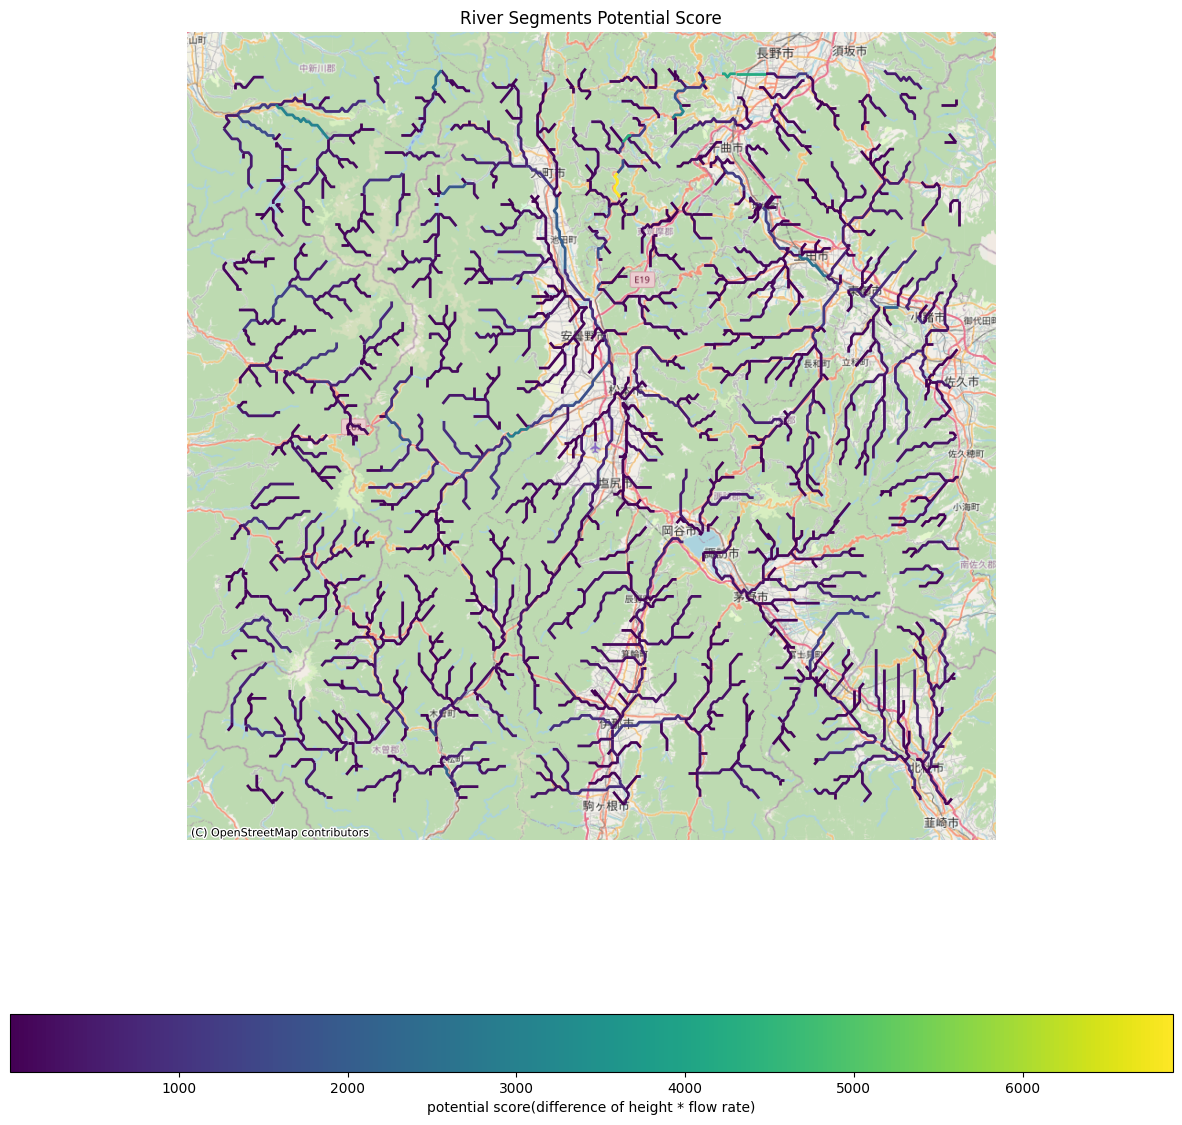

In [ ]:
# ■■■ 途中経過の可視化：河川ポテンシャルマップ ■■■

if 'rivers_utm' in locals() and not rivers_utm.empty and 'potential' in rivers_utm.columns:
    print("各河川セグメントのポテンシャルスコアを地図上にプロットします。")
    print("（ポテンシャルの値が高いほど、色が黄色に近くなります）")

    # 可視化のために、CRSをWebメルカトル(EPSG:3857)に変換
    rivers_to_plot = rivers_utm.to_crs(epsg=3857)

    # 0以下のポテンシャルは描画しても意味がないので除外
    rivers_to_plot = rivers_to_plot[rivers_to_plot['potential'] > 0]

    if not rivers_to_plot.empty:
        fig, ax = plt.subplots(1, 1, figsize=(15, 15))

        # 河川をポテンシャルスコアで色分けしてプロット
        rivers_to_plot.plot(ax=ax,
                            column='potential', # 色分けに使う列
                            cmap='viridis',     # カラーマップ（緑→黄）
                            linewidth=2,
                            legend=True,        # カラーバー（凡例）を表示
                            legend_kwds={'label': "potential score(difference of height * flow rate)",
                                         'orientation': "horizontal"})

        # 背景地図を追加
        cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)

        ax.set_title('River Segments Potential Score')
        ax.set_axis_off()
        plt.show()
    else:
        print("プロット対象となる、ポテンシャルが0より大きい河川がありませんでした。")

else:
    print("ポテンシャルスコアを計算済みの河川データが見つからないため、このセルは実行できません。")